# Lets go with Phase 1
exploring the data set

In [309]:
import pandas as pd
from google.colab import files
print("You are ready to go")

You are ready to go


In [310]:
df = pd.read_csv("diabetes.csv")

In [311]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [312]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [313]:
#I see we got no null values! lets go with the questions
#1 How many patients have diabetes versus those who don't?
outcome_counts = df['Outcome'].value_counts()
print(outcome_counts)

Outcome
0    500
1    268
Name: count, dtype: int64


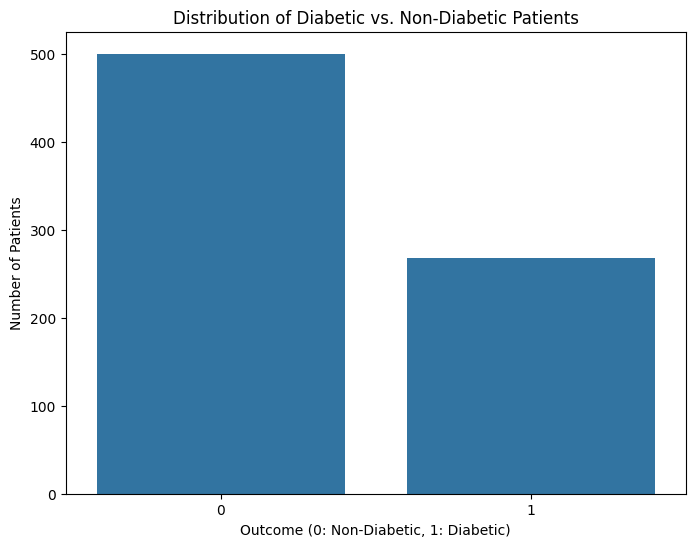

In [314]:
#adding some visuallization
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
sns.countplot(x="Outcome", data=df)
plt.title("Distribution of Diabetic vs. Non-Diabetic Patients")
plt.xlabel("Outcome (0: Non-Diabetic, 1: Diabetic)")
plt.ylabel("Number of Patients")
plt.show()

In [315]:
#2  What's the relationship between glucose levels and the outcome?
#trying to catch any relation between thus 2 columns
avg_glucose = df.groupby('Outcome')['Glucose'].mean()
print(avg_glucose)

Outcome
0    109.980000
1    141.257463
Name: Glucose, dtype: float64


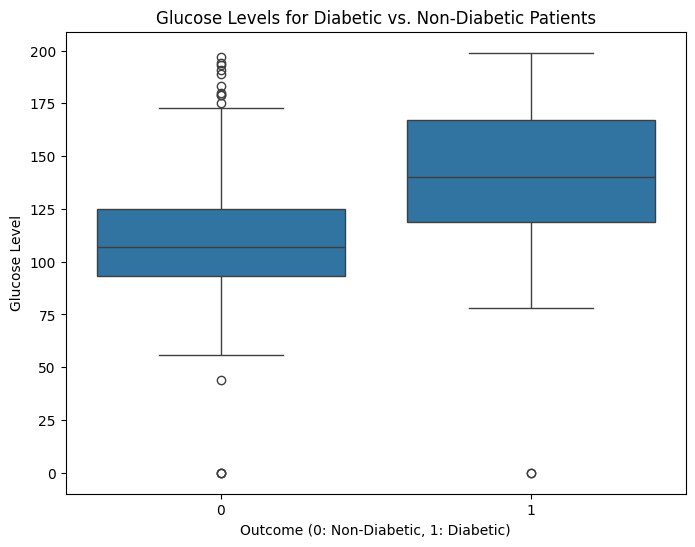

In [316]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Outcome', y='Glucose', data=df)
plt.title('Glucose Levels for Diabetic vs. Non-Diabetic Patients')
plt.xlabel('Outcome (0: Non-Diabetic, 1: Diabetic)')
plt.ylabel('Glucose Level')
plt.show()

In [317]:
#I see some relation by using the average
#go with question 3 :Does BMI play a significant role?
avg_bmi = df.groupby('Outcome')['BMI'].mean()
print(avg_bmi)

Outcome
0    30.304200
1    35.142537
Name: BMI, dtype: float64


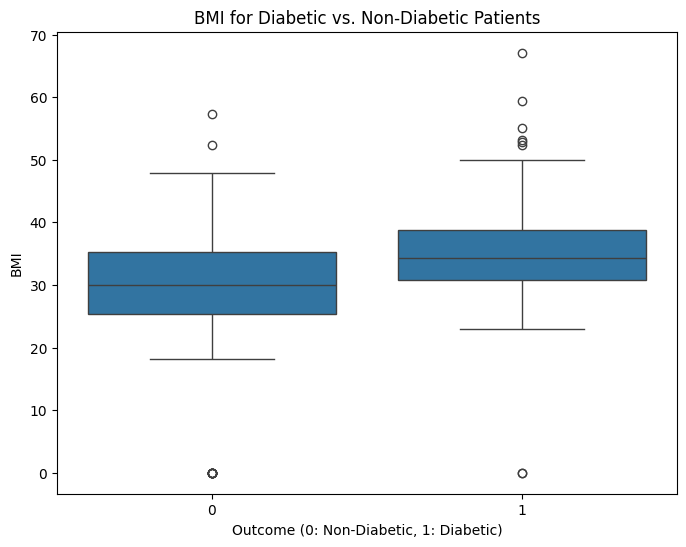

In [318]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Outcome', y='BMI', data=df)
plt.title('BMI for Diabetic vs. Non-Diabetic Patients')
plt.xlabel('Outcome (0: Non-Diabetic, 1: Diabetic)')
plt.ylabel('BMI')
plt.show()

Ok so i think iam done with Phase one with some notes


*   We have 500 non-diabetic and 268 diabetic patients in 768 rows with 9 columns
*   Glucose is a very important feature/predictor
*   BMI is not important as Glucose but it will help



# Phase 2 :Prep Your Data for Prime Time
start to standardizing our features and go on

In [319]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np


In [320]:
zero_features = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[zero_features] = df[zero_features].replace(0, np.nan)
print(df.isnull().sum())


Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [321]:
#Replace the zero values by medians with gropung by outcome
for feature in zero_features:
    median_diabetic = df[df['Outcome'] == 1][feature].median()
    median_non_diabetic = df[df['Outcome'] == 0][feature].median()

    df.loc[(df[feature].isna()) & (df['Outcome'] == 1), feature] = median_diabetic
    df.loc[(df[feature].isna()) & (df['Outcome'] == 0), feature] = median_non_diabetic
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [322]:
print(df[zero_features].describe())

          Glucose  BloodPressure  SkinThickness     Insulin         BMI
count  768.000000     768.000000     768.000000  768.000000  768.000000
mean   121.677083      72.389323      29.089844  141.753906   32.434635
std     30.464161      12.106039       8.890820   89.100847    6.880498
min     44.000000      24.000000       7.000000   14.000000   18.200000
25%     99.750000      64.000000      25.000000  102.500000   27.500000
50%    117.000000      72.000000      28.000000  102.500000   32.050000
75%    140.250000      80.000000      32.000000  169.500000   36.600000
max    199.000000     122.000000      99.000000  846.000000   67.100000


In [323]:
df['Glucose_BMI_Ratio'] = df['Glucose'] / df['BMI']
df['BloodPressure_BMI_Ratio'] = df['BloodPressure'] / df['BMI']
df['Age_BMI_Ratio'] = df['Age'] / df['BMI']
df['Insulin_Glucose_Ratio'] = df['Insulin'] / df['Glucose']

<Axes: >

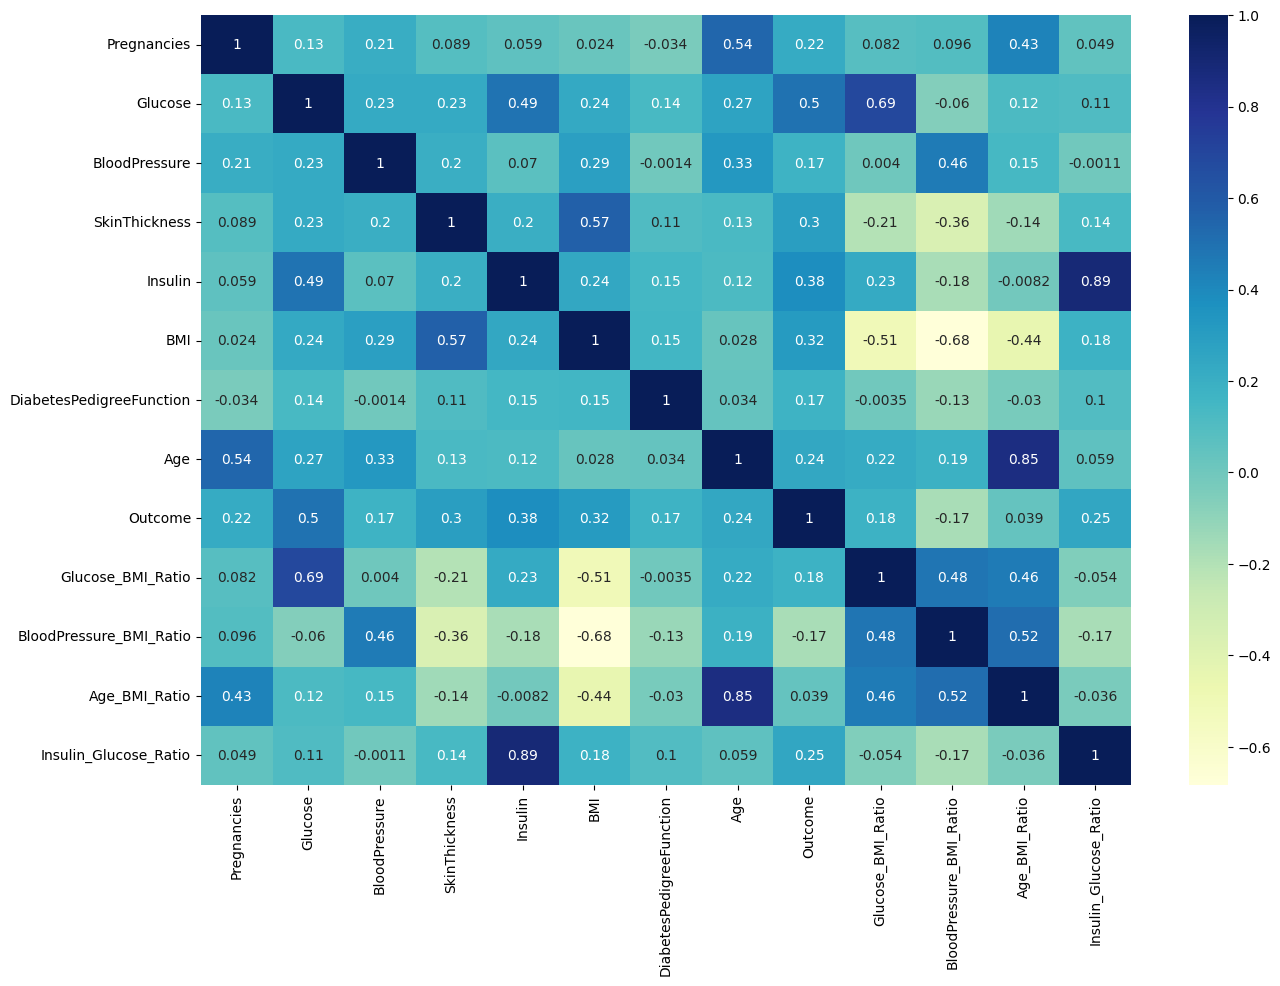

In [324]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(),annot=True,cmap="YlGnBu")

In [325]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled[:5])

X_train shape: (614, 12)
X_test shape: (154, 12)
[[-0.85135507 -1.0568694  -0.82668697 -1.8952899  -1.17037761 -0.76615019
   0.31079384 -0.79216928 -0.51919054 -0.04524204 -0.4190177  -1.27933701]
 [ 0.35657564  0.1428554   0.4770088  -0.22473578 -1.42764161 -0.41444809
  -0.11643851  0.56103382  0.35384979  0.59009307  0.62335993 -1.88084797]
 [-0.5493724  -0.55698407 -1.15261091  1.22307779 -0.54559361  0.36222739
  -0.76486207 -0.70759409 -0.79569815 -1.1481568  -0.78800854 -0.45107846]
 [-0.85135507  0.80936917 -1.31557289 -0.22473578 -0.44146295 -0.39979383
   0.26231357 -0.36929331  0.96084727 -0.74874396 -0.20992352 -0.83436213]
 [-1.15333775 -0.89024096 -0.663725    1.11170751 -0.41083628  1.78369005
  -0.33762972 -0.96131967 -1.60483803 -1.55343278 -1.28377043 -0.03438004]]


# Phase 3: Build, Train and Compete!
I will go with 3 type of models


1.   Logistic Regression
2.   Random Forest
3.   SVM

Then I will choose the best of them


In [326]:
#start with the logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_log_reg = log_reg.predict(X_test_scaled)

print("Accuracy:", (accuracy_score(y_test, y_pred_log_reg)*100))

Accuracy: 71.42857142857143


In [327]:
#71.42 is not a good accuracy for medicine field , trying to get it up
from sklearn.model_selection import GridSearchCV

log_reg = LogisticRegression(solver='liblinear', random_state=42)

param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2']
}

grid_search = GridSearchCV(estimator=log_reg, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)#I will go with 5 croos validiation
grid_search.fit(X_train_scaled, y_train)

print("Best parameters found:", grid_search.best_params_)

best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test_scaled)

print("New Accuracy:", accuracy_score(y_test, y_pred_best)*100)


Best parameters found: {'C': 0.001, 'penalty': 'l2'}
New Accuracy: 73.37662337662337


73.37 is a bit higher

In [328]:
#here the random forest go
from sklearn.ensemble import RandomForestClassifier
rand_forest = RandomForestClassifier(random_state=42)
rand_forest.fit(X_train_scaled, y_train)

y_pred_rand_forest = rand_forest.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_rand_forest)*100)

Accuracy: 88.31168831168831


In [329]:
#the accuracy gose to about 88.31% ,i will try to get it better
rand_forest = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10,20,30, None],
    'min_samples_leaf': [1, 2, 4, 8 , 12]
}


grid_search_rf = GridSearchCV(estimator=rand_forest, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2, scoring='accuracy')#3 cross validiation

grid_search_rf.fit(X_train_scaled, y_train)

print("Best parameters for Random Forest:", grid_search_rf.best_params_)

best_rf_model = grid_search_rf.best_estimator_
y_pred_best_rf = best_rf_model.predict(X_test_scaled)

print("New Accuracy:", accuracy_score(y_test, y_pred_best_rf)*100)


Fitting 3 folds for each of 40 candidates, totalling 120 fits
Best parameters for Random Forest: {'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 100}
New Accuracy: 88.31168831168831


Great! we make it up to 88.31% , lets try with another model


In [330]:
#SVM is on the line
from sklearn.svm import SVC

svm_model = SVC(random_state=42)
svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_svm)*100)


Accuracy: 83.11688311688312


In [331]:
#got a 83.11% , trying to hypernate
param_grid = {
    'C': [0.1, 1, 10, 100,200],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

grid_search_svm = GridSearchCV(estimator=svm_model, param_grid=param_grid, cv=5, verbose=2, n_jobs=-1)

grid_search_svm.fit(X_train_scaled, y_train)

print("\nBest parameters for SVM:", grid_search_svm.best_params_)
best_svm_model = grid_search_svm.best_estimator_
y_pred_best_svm = best_svm_model.predict(X_test_scaled)
print("New Accuracy:", accuracy_score(y_test, y_pred_best_svm)*100)



Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best parameters for SVM: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
New Accuracy: 83.11688311688312


After trying all the models and tring to tune it thats what we got


*   Accuracy: 70.78% for the hyperprameter linear regression
*   Accuracy: 88.31% for the base and hyperprameter Random forest
*   Accuracy: 83.11% for the base and hyperparameter svm



> final score go to the random forest tree model with 88.31%




# Phase 4: Launch Your Prediction Engine!
I will use hypernated random forest for that phase


In [332]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

def predict_diabetes():

    print("Please enter the following patient information:")

    pregnancies = float(input("Pregnancies: "))
    glucose = float(input("Glucose: "))
    blood_pressure = float(input("BloodPressure: "))
    skin_thickness = float(input("SkinThickness: "))
    insulin = float(input("Insulin: "))
    bmi = float(input("BMI: "))
    dpf = float(input("DiabetesPedigreeFunction: "))
    age = float(input("Age: "))

    glucose_bmi_ratio = glucose / bmi
    bp_bmi_ratio = blood_pressure / bmi
    age_bmi_ratio = age / bmi
    insulin_glucose_ratio = insulin / glucose

    features = np.array([[pregnancies, glucose, blood_pressure, skin_thickness,
                         insulin, bmi, dpf, age, glucose_bmi_ratio,
                         bp_bmi_ratio, age_bmi_ratio, insulin_glucose_ratio]])

    prediction = model.predict(features)[0]
    probability = model.predict_proba(features)[0][1]

    print(f"\nPrediction: {'Diabetic' if prediction == 1 else 'Non-Diabetic'}")
    print(f"Probability of diabetes: {probability:.2%}")
predict_diabetes()


Please enter the following patient information:


KeyboardInterrupt: Interrupted by user